# Linear Theta Analysis of XY Tests at LBL petal0 on Jan 2026

This notebook is in `/global/cfs/cdirs/desi/engineering/focalplane/linphi/Feb2024` at NERSC which is also accessible at the URL https://data.desi.lbl.gov/desi/engineering/focalplane/linphi/Feb2024/

use "DESI master" kernel

### Imports

In [1]:
import pathlib
import warnings
import json
import re

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm
from matplotlib.colors import Normalize

In [3]:
import pandas as pd

In [4]:
pd.set_option('display.max_colwidth', 100)

In [5]:
import scipy.optimize
import scipy.stats

In [6]:
from astropy.table import Table

In [7]:
import desimeter.transform.pos2ptl
import desimeter.transform.ptl2fp

## Calibration

Load the calibration parameters to use. The CSV file was created using
```
cd ~fpa_expert/dkirkby
./getdata.py --calib calib-20240224.csv
```
which was run on 20240224.

In [8]:
def load_calib(name):
    calib = pd.read_csv(name, index_col='pos_id')
    return calib

In [9]:
# C = load_calib('calib-20230821-petal0.csv')
# C = load_calib('/global/cfs/cdirs/desi/users/abault/linphi/calib-20241115-petal0.csv')
C = load_calib('calib-20241115-petal0.csv')

## Move Data

Load data from the positioner moves DB for a single exposure.  Most columns are straight from the [database schema](https://docs.google.com/spreadsheets/d/1e8yyjNFI9nCOT_KsJAxI3uzl8qSKqhuiDVXtXvxHNqM/edit#gid=836120262), with the following additions:
 - dx, dy: measured OBS_X,Y of stationary robots relative to the average over all iterations for a single exposure, in microns. Moving robots have NaN values here.
 - dx_turb, dy_turb: estimated turbulence corrections derived from a Gaussian process model, in microns. Equal to dx, dy for stationary robots.

To get this data, login to beyonce and extract DB moves (from `~dkirkby`):
```
./getdata.py --site petal0 --start "2024-02-24 03:15:00+00:00" --stop "2024-02-24 05:30:00+00:00"
```
but of course change the start and stop times to match the sequence you're downloading moves for.

Files will be saved in `~/dkirkby/moves/moves-{expid}.csv`, so you'll need to know the expid from petal0

In [10]:
def load_moves(expid, path='moves', pat='moves-{expid}.csv', petals=None):
    name = pathlib.Path(path) / pat.format(expid=expid)
    moves = pd.read_csv(name, parse_dates=['time_recorded'], low_memory=False)
    if petals is not None:
        sel = np.isin(moves.location // 1000, petals)
        print(f'Keeping {np.count_nonzero(sel)} / {len(sel)} moves in petals {petals}')
        moves = moves[sel]
    niter = len(np.unique(moves.exposure_iter))
    print(f'Read {niter} exposure iterations')
    return moves

Load getdata results:

In [11]:
#moves = load_moves(7047)
moves = load_moves(7066)

Read 58 exposure iterations


## Applied Scale Factors

In [12]:
scales_lintheta = pd.read_csv('scales/petal0_lintheta_scales.csv', index_col='DEVICE_ID')

In [13]:
scales_lintheta

,CURRENT,CW_SCALE_A,CCW_SCALE_A,MOTOR
DEVICE_ID,,,,
M06776,100,0.644,0.462,theta
M06841,100,0.256,0.664,theta
M07198,100,0.387,0.569,theta
M07784,100,0.500,0.770,theta


## XY Grid Analysis

In [14]:
def extract_fields(moves, colname, key, delims='()'):

    if key.endswith('TP'):
        subkeys = ('T', 'P')
    elif key.endswith('XYZ'):
        subkeys = ('X', 'Y', 'Z')
    elif key.endswith('XY'):
        subkeys = ('X', 'Y')
    elif key.endswith('dXdY'):
        subkeys = ('dX', 'dY')
    else:
        subkeys = ()

    start = f'{key}'
    if subkeys:
        start += f'={delims[0]}'
        stop = delims[1]
    else:
        stop = ';'

    if start.endswith('SCALE_A'):
        start += '='

    def extract(note):
        i1 = note.index(start)
        try:
            i2 = note.index(stop, i1)
        except ValueError:
            i2 = len(note)
        values = note[i1 + len(start):i2]
        if subkeys:
            return [float(value) for value in values.split(',')]
        else:
            return float(values)

    sel = moves[colname].notna() & moves[colname].str.contains(key)
    extracted = moves.loc[sel, colname].apply(extract)

    if subkeys:
        key = key[:-len(''.join(subkeys))]
        for k, subkey in enumerate(subkeys):
            col = f'{key}_{subkey}'
            moves[col] = np.nan
            moves.loc[sel, col] = extracted.apply(lambda v: v[k])
    else:
        moves[key] = np.nan
        moves.loc[sel, key] = extracted

    return moves

In [15]:
def ptl2int(x_ptl, y_ptl, offset_x, offset_y, length_r1, length_r2, offset_t, offset_p, t_int_guess=None):
    """Transform from ptl (x,y) to internal angles (t,p).
    """
    x_flat, y_flat = desimeter.transform.pos2ptl.ptl2flat(x_ptl, y_ptl)
    x_loc = desimeter.transform.pos2ptl.flat2loc(x_flat, offset_x)
    y_loc = desimeter.transform.pos2ptl.flat2loc(y_flat, offset_y)
    t_int, p_int, unreachable = desimeter.transform.pos2ptl.loc2int(
        x_loc, y_loc, length_r1, length_r2, offset_t, offset_p,
        t_int_guess=t_int_guess, t_guess_tol=90)
    if np.any(unreachable):
        warnings.warn(f'{np.count_nonzero(unreachable)} / {len(unreachable)} unreachable')
    return x_loc, y_loc, t_int, p_int

In [16]:
def pproc_xy(moves, calib):

    # Define calibration lookup function
    getcalib = lambda name: calib.loc[moves.pos_id, name].to_numpy()

    # Extract fields from the log_note column
    extract_fields(moves, 'log_note', 'submove')
    extract_fields(moves, 'log_note', 'req_posintTP')
    extract_fields(moves, 'log_note', 'req_ptlXYZ')
    extract_fields(moves, 'log_note', 'tCCW_SCALE_A')
    extract_fields(moves, 'log_note', 'tCW_SCALE_A')

    # Extract fields from the move_cmd column
    extract_fields(moves, 'move_cmd', 'poslocdXdY', delims='[]')  # only present for submove 1

    # Calculate and save the sum of commanded T,P moves from the moves_valN columns
    def sum_move(col_in, col_out):
        moves[col_out] = 0.
        valid = moves[col_in].notna()
        angle = moves[col_in].dropna().str.split('; | ').apply(
            lambda d: np.sum(np.array(list(map(float, d[1::2])))))
        moves.loc[valid, col_out] = angle
        #moves.drop(columns=col_in, inplace=True) # Drop the original string column
    sum_move('move_val1', 'req_dt')
    sum_move('move_val2', 'req_dp')

    # Calculate internal T,P angles from the FVC-measured ptl X,Y
    x_ptl, y_ptl = moves.ptl_x.to_numpy(), moves.ptl_y.to_numpy()
    x_loc, y_loc, t_int, p_int = ptl2int(
        x_ptl, y_ptl,
        getcalib('offset_x'), getcalib('offset_y'),
        getcalib('length_r1'), getcalib('length_r2'),
        getcalib('offset_t'), getcalib('offset_p'),
        t_int_guess=moves.pos_t.to_numpy())

    # Check if we need to add/subtract 360 deg to internal theta to avoid wrap around.
    range_t = getcalib('physical_range_t')
    alpha = (range_t - 360) / 2
    lo_wrap = (t_int < -180 + alpha) & (moves.pos_t > 180 - alpha)
    hi_wrap = (t_int > 180 - alpha) & (moves.pos_t < -180 + alpha)
    t_int[lo_wrap] += 360
    t_int[hi_wrap] -= 360
    moves['lo_wrap'] = lo_wrap
    moves['hi_wrap'] = hi_wrap

    moves['fvc_t'] = t_int
    moves['fvc_p'] = p_int
    moves['fvc_loc_x'] = x_loc
    moves['fvc_loc_y'] = y_loc

    # Calculate the changes in angles between moves based on FVC spots
    byloc = moves.groupby('location')
    moves['last_t'] = byloc.fvc_t.shift(+1, fill_value=np.nan)
    moves['last_p'] = byloc.fvc_p.shift(+1, fill_value=np.nan)
    moves['act_dt'] = moves.fvc_t - moves.last_t
    moves['act_dp'] = moves.fvc_p - moves.last_p

In [17]:
pproc_xy(moves, C)

## Plots

In [18]:
def plot_xy(moves, calib, pos_id='M03935', size_mm=4, scales=(0,0), path=None):

    motor = 'theta'

    M = moves[moves.pos_id == pos_id]
    #print(M)
    cal = calib.loc[pos_id]
    # Lookup arm lengths in mm
    r1 = cal.length_r1
    r2 = cal.length_r2
    # Lookup hole center in flat_XY coords
    xc_calib = cal.offset_x
    yc_calib = cal.offset_y
    # Convert to ptl_XY coords
    xc_calib, yc_calib = desimeter.transform.pos2ptl.flat2ptl(xc_calib, yc_calib)

    #PLOT
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.subplots_adjust(left=0.05, right=0.99, bottom=0.05, top=0.99, wspace=0.2, hspace=0.1)

    # 2D plot in LOC_X,Y
    ax = axes[0,0]
    ax.set(aspect=1, xlabel='poslocX [mm]', ylabel='poslocY [mm]',
          xlim=(-size_mm, +size_mm), ylim=(-size_mm, +size_mm))
    ax.text(0.05, 0.95, f'{pos_id} r1={r1:.1f}mm r2={r2:.1f}mm', transform=ax.transAxes)

    I0 = M.submove == 0
    I1 = M.submove == 1
    ax.scatter(M.fvc_loc_x[I0], M.fvc_loc_y[I0], c=M.exposure_iter[I0], lw=0.5, edgecolor='k', cmap='Blues', s=50, marker='o', label='submove 0')
    ax.scatter(M.fvc_loc_x[I1], M.fvc_loc_y[I1], c='none', lw=0.5, edgecolor='k', s=50, marker='s', label='submove 1')
    ax.plot(M.fvc_loc_x, M.fvc_loc_y, 'b-', lw=1, alpha=0.2)
    ax.plot(0, 0, 'rx')
    ax.legend(loc='lower right', fontsize=8, ncol=1)

    # Phi vs exposure iteration
    ax = axes[0,1]
    ax.set(xlabel='Exposure Iter', ylabel='poslocP [deg]', ylim=(0,200))
    ax.grid(which='major', color='lightgray', linestyle=':', axis='y')
    ax.scatter(M.exposure_iter[I0], M.fvc_p[I0], c=M.exposure_iter[I0], lw=0.5, edgecolor='k', cmap='Blues', s=50, marker='o', label='submove 0')
    ax.scatter(M.exposure_iter[I1], M.fvc_p[I1], c='none', lw=0.5, edgecolor='k', s=50, marker='s', label='submove 1')
    ax.plot(M.exposure_iter, M.fvc_p, 'b-', lw=1, alpha=0.2)
    ax.plot(M.exposure_iter, M.req_posint_P, 'r.', ms=3, label='request')
    ax.legend(loc='lower right', fontsize=8, ncol=3)

    # Theta vs exposure iteration
    ax = axes[1,1]
    #lim = (np.min(M.fvc_t)-30, np.max(M.fvc_t)+20)
    ax.set(xlabel='Exposure Iter', ylabel='poslocT [deg]', ylim=(-200,200))
    ax.grid(which='major', color='lightgray', linestyle=':', axis='y')
    ax.scatter(M.exposure_iter[I0], M.fvc_t[I0], c=M.exposure_iter[I0], lw=0.5, edgecolor='k', cmap='Blues', s=50, marker='o', label='submove 0')
    ax.scatter(M.exposure_iter[I1], M.fvc_t[I1], c='none', lw=0.5, edgecolor='k', s=50, marker='s', label='submove 1')
    ax.plot(M.exposure_iter, M.fvc_t, 'b-', lw=1, alpha=0.2)
    ax.plot(M.exposure_iter, M.req_posint_T, 'r.', ms=3, label='request')
    ax.legend(loc='lower right', fontsize=8, ncol=3)

    # Requested vs actual delta(theta) for each submove
    for submove in (0,1):
        sel = M.submove == submove
        req, act = np.array(M[sel].req_dt), np.array(M[sel].act_dt)
        xlabel = 'Requested dT [deg]'
        ylabel = 'Actual dT [deg]'
        #lim = [360,50][submove]
        lim = 50

        ax = axes[submove, 2]
        ax.set(aspect=1, xlim=(-lim,lim), ylim=(-lim,lim), xlabel=xlabel, ylabel=ylabel)
        ax.text(0.05, 0.95, f'{pos_id}\nCW / CCW={scales[0]:.3f} / {scales[1]:.3f}\nsubmove {submove}', va='top', transform=ax.transAxes)
        ax.grid(linestyle=':')
        ax.plot([-lim,lim],[-lim,lim], 'r--', lw=0.5, alpha=0.5)
        ax.plot(req, act, '.')

    # Get blind move residuals from posloc_dXY in the move_cmd of the correction move
    dx0 = 1e3 * M.posloc_dX[I1]
    dy0 = 1e3 * M.posloc_dY[I1]
    dr0 = np.hypot(dx0, dy0)

    ax = axes[1,0]
    bins = np.linspace(0, 250, 51)
    ax.set(xlabel='Positioning error [microns]', xlim=(bins[0], bins[-1]))
    ax.hist(dr0, bins=bins, histtype='step', hatch='/', label='Blind Move')
    ax.legend()

    # Calculate and display statistics
    blindErrMax = np.max(dr0)
    blindErr95 = np.nanpercentile(dr0, 95)
    label = f'MAX blind: 100% < {blindErrMax:.1f}um 95% < {blindErr95:.1f}um\n'
    ax.text(0.95, 0.5, label, va='center', ha='right', transform=ax.transAxes)

    if path is not None:
        plt.savefig(f'{path}/{pos_id}.jpg')

    return pos_id, blindErrMax, blindErr95

In [19]:
petal0_linthetas = ['M06776', 'M06841', 'M07198', 'M07784']

In [20]:
def plot_all(linphis, moves, scales, path):
    rows = [ ]
    for posid in linphis:
        try:
            row = scales.loc[posid]
            cw, ccw = row.CW_SCALE_A, row.CCW_SCALE_A
            rows.append(plot_xy(moves, C, posid, scales=(cw, ccw), path=path))
        except Exception as e:
            print(posid, 'ERROR:', e)
        plt.clf()
        plt.close()
    stats = pd.DataFrame(rows, columns=('posid', 'blindMax', 'blind95'))
    stats.set_index('posid', inplace=True)
    return stats

In [22]:
stats = plot_all(petal0_linthetas, moves, scales_lintheta, 'plots/7066/')
print(stats)

           blindMax      blind95
posid                           
M06776  2295.033852  2264.603258
M06841  2750.954111  2362.268786
M07198   663.176012   355.044698
M07784   543.861990   240.943771


In [36]:
def save_xy(moves, posids, scales, stats, fit=False, save='moves.json', motor = 'phi'):

    assert motor in ['phi', 'theta']

    data = { }
    ##f = open('mar24-updated.csv', 'w')
    ##print('posid,cw,ccw', file=f)
    for posid in posids:
        if posid not in scales.index:
            continue
        scale = scales.loc[posid]
        appliedScaleCW = scale.CW_SCALE_A
        appliedScaleCCW = scale.CCW_SCALE_A

        if not posid in stats.index:
            continue
        stat = stats.loc[posid]

        if motor == 'phi':
            M = moves[(moves.pos_id == posid) & moves.act_dp.notna() & moves.submove.notna() & (moves.req_dp != 0)]
        if motor == 'theta':
            M = moves[(moves.pos_id == posid) & moves.act_dt.notna() & moves.submove.notna() & (moves.req_dt != 0)]

        if fit:
            try:
                if motor == 'phi':
                    finalParameters, initialNLP, finalNLP, predicted = fitLinearMotor(
                        M.req_dp, M.act_dp, appliedScaleCW, appliedScaleCCW)
                if motor == 'theta':
                    finalParameters, initialNLP, finalNLP, predicted = fitLinearMotor(
                        M.req_dt, M.act_dt, appliedScaleCW, appliedScaleCCW)
                S, dS, dC, dR = [float(x) for x in np.round(finalParameters,5)]
            except RuntimeError as e:
                print(f'Cannot fit {posid}: {e}')
                continue
        else:
            S = (appliedScaleCW + appliedScaleCCW) / 2
            dC = (appliedScaleCCW - appliedScaleCW) / 2
            dS = 0
            dR = 0

        info = dict(
            appliedCruiseScaleCW=appliedScaleCW, appliedCruiseScaleCCW=appliedScaleCCW,
            S=S, dS=dS, dC=dC, dR=dR,
            blindMax=stat.blindMax, blind95=stat.blind95, corr30=stat.corr30, corr20=stat.corr20, corrRms=stat.corrRms
        )
        #'blindMax', 'blind95', 'corr30', 'corr20', 'corrRms'

        Ccw = S + dS - dC
        Cccw = S + dS + dC

        ##print(f'{posid} CW/CCW={Ccw:.2f}/{Cccw:.2f} S={S:.3f} dS={dS:.3f} dC={dC:.3f} dR={dR:.3f} corrRms={stat.corrRms:.1f}um')
        ##print(f'{posid},{Ccw:.4f},{Cccw:.4f}', file=f)

        sub = [int(x) for x in M.submove]
        if motor == 'phi':
            req = [float(x) for x in np.round(M.req_dp, 4)]
            act = [float(x) for x in np.round(M.act_dp, 4)]
        if motor == 'theta':
            req = [float(x) for x in np.round(M.req_dt, 4)]
            act = [float(x) for x in np.round(M.act_dt, 4)]
        info['moves'] = [ dict(sub=sub[i], req=req[i], act=act[i]) for i in range(len(M)) ]
        data[posid] = info

    ##f.close()
    with open(save, 'w') as f:
        json.dump(data, f, indent=2)

#save_xy(moves226836, real_linphis, applied_scales)

In [37]:
save_xy(moves6981, petal0_linthetas, scales_lintheta, stats6981, fit=False, save = '20260130-6981.json')

In [ ]:
def fitLinearMotor(requestedAngle, actualAngle,
                   appliedCruiseScaleCW=1, appliedCruiseScaleCCW=1,
                   baseMoveDeg=5, cruiseStep=100, upRamp=1, downRamp=1,
                   rmsErrorMicrons=5, priorSigma=0.2, verbose=False,
                   maxOutlierIters=3, maxPull=15, minMoves=5):
    """ Fit 4 motor parameters to a set of (requested,actual) moves.

    Assumes that each requested move by A is converted into a pair of moves,
    (-B,A+B) or (A+B,-B), chosen to ensure a change of direction from the
    previous move, where B is the base move amount with the same sign as A.
    Also assumes that moves were performed with a move table translation
    where the nominal number of cruise steps is converted to
    round(nominalCruiseSteps/A) where A = appliedCruiseScaleCW/CCW.

    The motor's behavior is parameterized by four numbers parameters=[S,dS,dC,dR] that
    determine the scale factors for cruise (C) and ramps (R) in the CW (s=-1) and CCW (s=+1)
    directions via:

      Cs = S + dS + s dC   Rs = S - dS + s dR

    See https://observablehq.com/@dkirkby/linphi for an interactive version of this model.

    Returns a tuple (finalParameters, initialNLP, finalNLP, predicted) where finalParameters
    are the best-fit (S,dS,dC,dR) values, initial/finalNLP are the values of the -log(posterior)
    before/after the fit, and predicted are the predicted angles for the best-fit model.

    Raises a RuntimeError in case the fit fails.
    """
    requestedAngle = np.atleast_1d(requestedAngle)
    if np.any(requestedAngle == 0):
        print(requestedAngle)
    actualAngle = np.atleast_1d(actualAngle)
    # Calculate the nominal conversion from phi degrees to tangent-plane microns.
    deg2um = 3000 * np.pi / 180
    # Calculate the total number of ramp up+down 18 kHz ticks.
    def ramp(cruiseStep, spinStep):
        return np.concatenate([ np.full(spinStep, n) for n in range(cruiseStep + 1) ])
    nominalRampSteps = ramp(cruiseStep, upRamp).sum() + ramp(cruiseStep, downRamp).sum()
    # Estimate the average scale factor for these moves. Don't distinguish between CW/CCW here.
    avgApplied = (appliedCruiseScaleCW + appliedCruiseScaleCCW) / 2
    S = np.nanmedian(actualAngle / requestedAngle * avgApplied)
    initialParameters = np.array([S, 0, 0, 0])
    # Insert base moves. We don't worry about the order here since we already
    # assume a change of direction between moves.
    reqSign = np.sign(requestedAngle)
    B = reqSign * baseMoveDeg
    moveAngles = np.stack((np.full_like(requestedAngle, -B), requestedAngle + B), axis=1)
    # Initialize a mask of non-outlier moves to fit.
    mask = np.ones(len(requestedAngle), bool)
    # Define a -log(posterior probability) function to minimize.
    pulls = np.zeros_like(requestedAngle)
    def NLP(parameters):
        # Predict angles for each phase.
        angles = predictAngle(parameters, moveAngles, 1.2, True,
                              appliedCruiseScaleCW, appliedCruiseScaleCCW,
                              cruiseStep, nominalRampSteps)
        # Calculate net move from (-B,A+B) sequence.
        predicted = angles.sum(axis=1)
        # Calculate pulls from residuals in microns.
        pulls[:] = (predicted - actualAngle) * deg2um / rmsErrorMicrons
        # Calculate the corresponding -log(likelihood) = chiSquare / 2 using
        # only the unmasked moves.
        negLogLike = 0.5 * np.sum(pulls[mask] ** 2)
        # Apply Gaussian priors to the poorly determined dS,dC,dR parameters.
        negLogPrior = np.sum(parameters[1:] ** 2) / (2 * priorSigma ** 2)
        return negLogLike + negLogPrior
    # Perform the fit.
    initialNLP = NLP(initialParameters)
    iterNum = 0
    while iterNum < maxOutlierIters:
        fit = scipy.optimize.minimize(NLP, initialParameters, method='Nelder-Mead', options=dict(disp=verbose))
        if not fit.success:
            raise RuntimeError(fit.message)
        finalParameters = fit.x
        predicted = predictAngle(finalParameters, moveAngles, 1.2, True,
                                 appliedCruiseScaleCW, appliedCruiseScaleCCW,
                                 cruiseStep, nominalRampSteps).sum(axis=1)
        if np.all(np.abs(pulls) <= maxPull):
            break
        mask = np.abs(pulls) <= maxPull
        if np.count_nonzero(mask) < minMoves:
            raise RuntimeError(f'Not enough moves to fit ({minMoves}) after outlier masking.')
        iterNum += 1
    finalNLP = NLP(finalParameters)
    return finalParameters, initialNLP, finalNLP, predicted

fitLinearMotor([5,-5], [5,-2.5], 1, 1)

(array([0.75, 0.  , 0.  , 0.  ]),
 156.5,
 156.5,
 array([ 3.73488889, -3.73488889]))

In [ ]:
def predictAngle(parameters, requestedAngle, backlash, changeDir,
                 appliedCruiseScaleCW, appliedCruiseScaleCCW,
                 cruiseStep, nominalRampSteps, gearRatio = (46 / 14 + 1) ** 4):
    """ Predict the actual motion of a linear phi motor corresponding to a requested angle.

    The motor's behavior is parameterized by four numbers parameters=[S,dS,dC,dR] that
    determine the scale factors for cruise (C) and ramps (R) in the CW (s=-1) and CCW (s=+1)
    directions via:

      Cs = S + dS + s dC   Rs = S - dS + s dR

    Assumes that moves were performed with a move table translation where the nominal
    number of cruise steps is converted to round(nominalCruiseSteps/A) where
    A = appliedCruiseScaleCW/CCW.

    See https://observablehq.com/@dkirkby/linphi for an interactive version of this model.
    """
    requestedAngle = np.asarray(requestedAngle)
    reqSign = np.sign(requestedAngle)
    reqDir = (1 + reqSign) / 2;
    appliedCruiseScale = reqDir * appliedCruiseScaleCCW + (1 - reqDir) * appliedCruiseScaleCW

    S, dS, dC, dR = parameters
    trueCruiseScale = S + dS + reqSign * dC
    trueRampScale = S - dS + reqSign * dR

    nominalCruiseTicks = np.round((reqSign * requestedAngle * gearRatio * 10 - nominalRampSteps) / cruiseStep)
    actualCruiseTicks = np.round(nominalCruiseTicks / appliedCruiseScale)

    disengagedDeg = reqSign * np.float64(changeDir) * backlash
    return reqSign / (10 * gearRatio) * (
        trueRampScale * nominalRampSteps + trueCruiseScale * actualCruiseTicks * cruiseStep) - disengagedDeg

In [82]:
actualAngle([1,0,0,0], [-5,10], 1.2, [True,True], 1, 1, 100, 10100)

array([-3.80949383,  8.78934568])

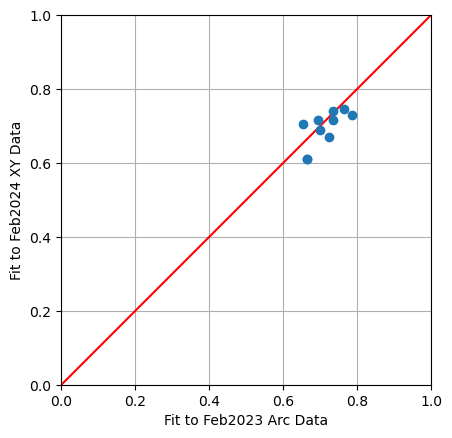

In [ ]:
def plot_scatter():

    feb23_cw = np.array([0.77, 0.74, 0.79, 0.67, 0.64, 0.69, 0.76, 0.69, 0.70, 0.73])
    feb23_ccw= np.array([0.70, 0.71, 0.78, 0.66, 0.67, 0.71, 0.77, 0.64, 0.69, 0.74])
    feb24_cw = np.array([0.74, 0.68, 0.72, 0.61, 0.69, 0.68, 0.76, 0.60, 0.74, 0.72])
    feb24_ccw= np.array([0.69, 0.66, 0.74, 0.61, 0.72, 0.70, 0.73, 0.62, 0.69, 0.76])

    feb23 = (feb23_cw + feb23_ccw) / 2
    feb24 = (feb24_cw + feb24_ccw) / 2

    ax = plt.gca()
    ax.plot([0,1],[0,1],c='r')
    ax.plot(feb23, feb24, 'o')
    ax.set(aspect=1, xlim=(0,1), ylim=(0,1), xlabel='Fit to Feb2023 Arc Data', ylabel='Fit to Feb2024 XY Data')
    ax.grid()
    plt.savefig('linphi-cmp.jpg')

plot_scatter()

## Robot Selection

Selected 43 / 90 robots
['M03935', 'M03986', 'M03981', 'M03696', 'M03735', 'M03929', 'M01875', 'M03661', 'M03607', 'M03650', 'M03654', 'M03649', 'M03820', 'M03642', 'M03680', 'M03584', 'M04213', 'M03889', 'M05086', 'M03983', 'M03609', 'M03742', 'M03645', 'M03633', 'M03950', 'M03941', 'M03464', 'M03913', 'M03653', 'M03455', 'M02164', 'M05496', 'M05052', 'M05362', 'M04379', 'M03711', 'M05048', 'M05053', 'M03656', 'M04310', 'M05007', 'M05376', 'M04981']


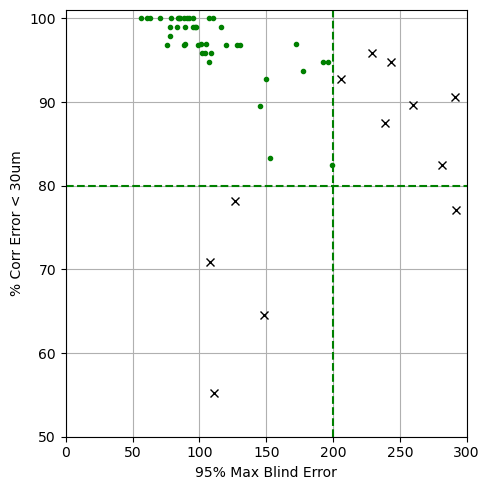

In [ ]:
def select(stats, scales, blind95cut=200, corr30cut=80):

    fig, ax = plt.subplots(figsize=(5,5))

    sel = (stats.blind95 < blind95cut) & (stats.corr30 > corr30cut)
    print(f'Selected {np.count_nonzero(sel)} / {len(sel)} robots')
    posids = list(stats[sel].index)
    print(posids)
    ax.plot(stats[~sel].blind95, stats[~sel].corr30, 'kx')
    ax.plot(stats[sel].blind95, stats[sel].corr30, 'g.')
    ax.set(xlim=(0,300), ylim=(50,101), xlabel='95% Max Blind Error', ylabel='% Corr Error < 30um')
    ax.grid()
    ax.axvline(blind95cut, c='g', ls='--')
    ax.axhline(corr30cut, c='g', ls='--')

    plt.tight_layout()
    plt.savefig('selection.jpg')

    return posids

keep = select(stats232453, scalesC)

In [401]:
from shutil import copy

In [403]:
expids = (232265, 232268, 232451, 232453, 232455)

In [409]:
def organize():
    P = pathlib.Path('VI')
    for posid in keep:
        for expid in expids:
            src = f'{expid}/{posid}.jpg'
            dst = f'VI/{posid}-{expid}.jpg'
            if not pathlib.Path(src).exists():
                print(f'Missing {src}')
            else:
                copy(src, dst)

organize()

Missing 232268/M03654.jpg


## Scale Sensitivity Study

Simulate blind + correction random moves within a patrol radius to study the sensitivity to scale errors. Moves are uniformly distributed with the patrol area, i.e.
$$
\frac{1}{N} dN/dr = \frac{r}{r^2_{max}/2}
$$
so the cummulative distribution function is
$$
C(r) \equiv  \frac{1}{r^2_{max}/2} \int_0^r r' dr' = (r / r_{max})^2
$$
and we can transform a uniform random deviate $0 < u < 1$ into a suitably distributed value of $r$ by solving
$$
u = C(r) \quad \Rightarrow \quad r = r_{max} \sqrt{u} \; .
$$

In [269]:
def tp2xy(T,P,r1=3,r2=3):
    TP = T + P
    x = r1 * np.cos(T) + r2 * np.cos(TP)
    y = r1 * np.sin(T) + r2 * np.sin(TP)
    return x, y

In [321]:
def xy2tp(x,y,r1=3,r2=3):
    Rsq = x ** 2 + y ** 2
    r1sq = r1 * r1
    r2sq = r2 * r2
    arccosP = (Rsq - r1sq - r2sq) / (2 * r1 * r2)
    P = np.arccos(np.clip(arccosP, -1, 1))
    T = np.arctan2(y, x) - np.arctan2(r2 * np.sin(P), r1 + r2 * np.cos(P))
    #s = (Rsq - r2sq + r1sq) / (2 * np.sqrt(Rsq))
    #a = np.sqrt(np.maximum(0, r1sq - s * s))
    #T = np.arctan2(y, x) - np.arctan2(a, s)
    return T, P

In [322]:
tp2xy(-0.1, 0.2)

(5.970024991668155, 0.0)

In [323]:
xy2tp(*tp2xy(-0.2, 0.1))

(-0.20000000000000032, 0.10000000000000057)

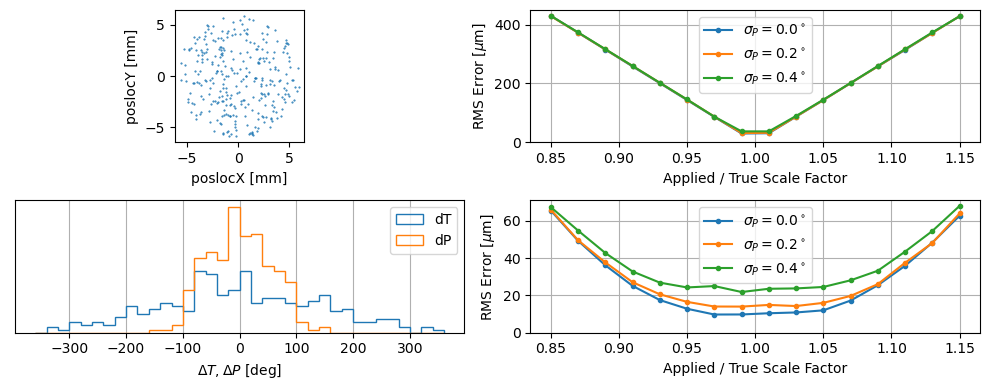

In [ ]:
def generateMoves(n, r1=3, r2=3, seed=123, blindRms=100, corrRms=5, dPratios=np.linspace(0.85, 1.15, 16), plot=False, save=None):

    # Generate (x,y) points uniformly distributed within a circle of radius r1+r2
    rng = np.random.default_rng(seed)
    r = (r1 + r2) * np.sqrt(rng.uniform(size=n+1))
    psi = 2 * rng.uniform(size=n+1) * np.pi
    x = r * np.cos(psi)
    y = r * np.sin(psi)

    # Convert from (x,y) to robot angles (T,P)
    T, P = xy2tp(x, y, r1, r2)
    dT = np.diff(T)
    dP = np.diff(P)

    # Check round trip back to (x,y)
    x2, y2 = tp2xy(T, P, r1, r2)
    assert np.all(np.hypot(x-x2, y-y2) < 1e-6)

    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(10, 4))
        ax = axes[0,0]
        ax.plot(x, y, '.', ms=1)
        ax.set(aspect=1, xlabel='poslocX [mm]', ylabel='poslocY [mm]')
        ax = axes[0,1]
        ax.grid()
        ax.set(xlabel='Applied / True Scale Factor', ylabel='RMS Error [$\mu$m]')
        ax = axes[1,0]
        bins = np.linspace(-360,360,37)
        ax.hist(np.rad2deg(dT), bins=bins, label='dT', histtype='step')
        ax.hist(np.rad2deg(dP), bins=bins, label='dP', histtype='step')
        ax.grid()
        ax.legend()
        ax.set(xlabel='$\Delta T,\Delta P$ [deg]', yticks=[])
        ax = axes[1,1]
        ax.grid()
        ax.set(xlabel='Applied / True Scale Factor', ylabel='RMS Error [$\mu$m]')

    PrmsVec = np.linspace(0, 0.4, 3)
    for Prms in PrmsVec:
        blindRmsVec = np.empty_like(dPratios)
        corrRmsVec = np.empty_like(dPratios)

        for k, dPratio in enumerate(dPratios):

            # Calculate the rescaled blind move P
            Tblind = T[1:]
            Pblind = P[:-1] + dPratio * dP
            if Prms > 0:
                Pblind = rng.normal(loc=Pblind, scale=np.deg2rad(Prms))

            # Calculate the corresponding (x,y) after the blind move
            xblind, yblind = tp2xy(Tblind, Pblind, r1, r2)

            # Apply blind-move random errors.
            if blindRms > 0:
                xblind = rng.normal(loc=xblind, scale=blindRms/np.sqrt(2)/1e3)
                yblind = rng.normal(loc=yblind, scale=blindRms/np.sqrt(2)/1e3)

            # Calculate blind-move residuals in microns
            dxblind = 1e3 * (xblind - x[1:])
            dyblind = 1e3 * (yblind - y[1:])

            blindRmsVec[k] = np.sqrt(np.var(dxblind) + np.var(dyblind))

            # Calculate the rescaled correction move.
            Tblind, Pblind = xy2tp(xblind, yblind, r1, r2)
            dPcorr = P[1:] - Pblind
            Tcorr = T[1:]
            Pcorr = Pblind + dPratio * dPcorr
            if Prms > 0:
                Pcorr = rng.normal(loc=Pcorr, scale=np.deg2rad(Prms))

            # Calculate the corresponding (x,y) after the correction move.
            xcorr, ycorr = tp2xy(Tcorr, Pcorr, r1, r2)

            # Apply correction-move random errors.
            if corrRms > 0:
                xcorr = rng.normal(loc=xcorr, scale=corrRms/np.sqrt(2)/1e3)
                ycorr = rng.normal(loc=ycorr, scale=corrRms/np.sqrt(2)/1e3)

            # Calculate correction move residuals in microns.
            dxcorr = 1e3 * (xcorr - x[1:])
            dycorr = 1e3 * (ycorr - y[1:])

            corrRmsVec[k] = np.sqrt(np.var(dxcorr) + np.var(dycorr))

        if plot:
            ax = axes[0,1]
            ax.plot(dPratios, blindRmsVec, '.-', label=f'$\sigma_P = {Prms:.1f}^\circ$')
            ax = axes[1,1]
            ax.plot(dPratios, corrRmsVec, '.-', label=f'$\sigma_P = {Prms:.1f}^\circ$')

    for ax in axes[:,1]:
        ax.legend()
        ax.set(ylim=(0,None))

    plt.tight_layout()
    if save:
        plt.savefig(save)


generateMoves(300, blindRms=10, corrRms=10, plot=True, save='sensitivity200.jpg')